# Criminalidade urbana no Rio Grande do Sul — análise por município

**Trabalho Final de Ciência de Dados — Tema 6.** Pergunta central: os tipos de
ocorrência têm padrão espacial (município / mesorregião) e temporal (dia,
horário) identificável no RS, a ponto de justificar priorização de recursos por
região?

**Fontes:** microdados de ocorrências da SSP-RS (2022–2025) e IBGE (Censo 2022,
população e mesorregiões). Preparação dos dados: `src/carga.py`, `src/ibge.py`,
`src/limpeza.py`.

## 1. Carga dos dados

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, kruskal

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))
import viz
viz.aplicar_estilo()

df = pd.read_parquet(RAIZ / "data" / "interim" / "ocorrencias_rs.parquet")
mun = pd.read_csv(RAIZ / "data" / "processed" / "municipios_taxa.csv")

# Reaplica a ordem das categorias temporais (o parquet pode perder o ordenamento).
df["nome_dia"] = pd.Categorical(df["nome_dia"], categories=viz.ORDEM_DIA, ordered=True)
df["turno"] = pd.Categorical(df["turno"], categories=viz.ORDEM_TURNO, ordered=True)

n_anos = df["ano"].nunique()
print(f"Ocorrencias: {len(df):,} | anos: {sorted(df['ano'].unique())} | "
      f"municipios: {df['municipio'].nunique()}")

Ocorrencias: 3,117,592 | anos: [np.float64(2022.0), np.float64(2023.0), np.float64(2024.0), np.float64(2025.0)] | municipios: 497


## 2. Análise exploratória (descritiva)

In [2]:
# Composicao por macrocategoria e recorte de crimes de rua (sensiveis a patrulha).
resumo = (df["macro"].value_counts(normalize=True) * 100).round(1)
print("Participacao por macrocategoria (%):")
print(resumo.to_string())
print(f"\nCrimes de rua: {df['crime_de_rua'].mean():.1%} das ocorrencias")

rua = df[df["crime_de_rua"]].copy()
print(f"Ocorrencias de crime de rua: {len(rua):,}")

Participacao por macrocategoria (%):
macro
AMEACA_VD             17.6
FRAUDE                17.2
OUTROS                13.0
FURTO_OUTROS          12.0
LESAO                  8.9
TRANSITO               6.7
HONRA_DISCRIM          4.5
DROGAS                 3.9
ORDEM_PUBLICA          3.1
ROUBO_RUA              2.6
DANO                   2.6
FURTO_VEICULO          2.2
FURTO_ARROMBAMENTO     1.8
ROUBO_OUTROS           1.4
SEXUAL                 1.1
ARMAS                  0.9
ROUBO_VEICULO          0.4
CVLI                   0.2

Crimes de rua: 33.4% das ocorrencias


Ocorrencias de crime de rua: 1,041,007


### 3. Quando o crime acontece — Figura 1

Heatmap de ocorrências de crime de rua por dia da semana × hora do dia.
Responde: existe concentração em faixas de horário/dia?

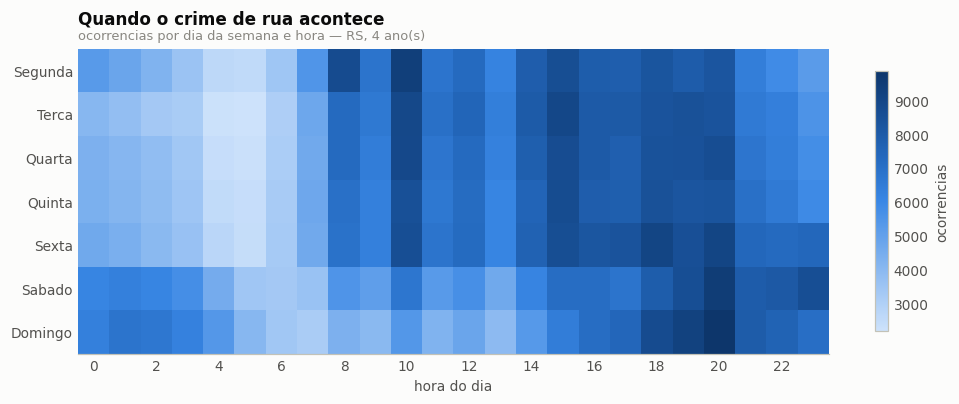

In [3]:
piv = (rua.pivot_table(index="nome_dia", columns="hora", aggfunc="size", observed=False)
          .reindex(index=viz.ORDEM_DIA).reindex(columns=range(24), fill_value=0).fillna(0))

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(piv.values, aspect="auto", cmap=viz.CMAP)
ax.set_xticks(range(0, 24, 2)); ax.set_xticklabels(range(0, 24, 2))
ax.set_yticks(range(7)); ax.set_yticklabels(viz.ORDEM_DIA)
ax.set_xlabel("hora do dia")
viz.limpar_grade(ax)
viz.titular(ax, "Quando o crime de rua acontece",
            f"ocorrencias por dia da semana e hora — RS, {n_anos} ano(s)")
fig.colorbar(im, ax=ax, shrink=0.85, label="ocorrencias")
viz.salvar(fig, "f1_heatmap_dia_hora"); plt.show()

### 4. Cada crime tem sua hora — Figura 2

Distribuição horária normalizada das principais macrocategorias. Responde: o
horário de pico depende do tipo de crime?

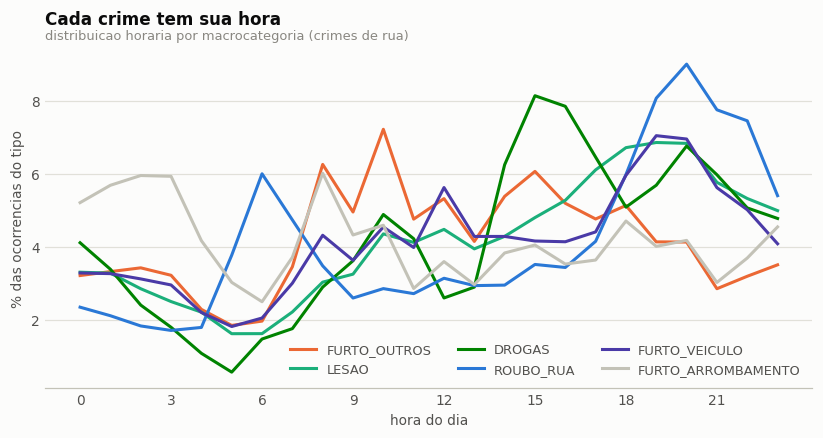

In [4]:
top = rua["macro"].value_counts().head(6).index
fig, ax = plt.subplots(figsize=(9, 4))
for m in top:
    s = (rua.loc[rua["macro"] == m, "hora"].value_counts(normalize=True)
            .reindex(range(24), fill_value=0).sort_index())
    ax.plot(s.index, s.values * 100, label=m, color=viz.cor_macro(m))
ax.set_xlabel("hora do dia"); ax.set_ylabel("% das ocorrencias do tipo")
ax.set_xticks(range(0, 24, 3))
ax.legend(ncol=3)
viz.titular(ax, "Cada crime tem sua hora",
            "distribuicao horaria por macrocategoria (crimes de rua)")
viz.salvar(fig, "f2_perfil_horario_por_tipo"); plt.show()

### 5. Onde a taxa é maior — Figura 3

Taxa média anual por 100 mil habitantes, top 15 municípios. **Atenção:** a
população é a residente (Censo 2022); municípios litorâneos aparecem inflados
pela população flutuante de veraneio — ver limitações.

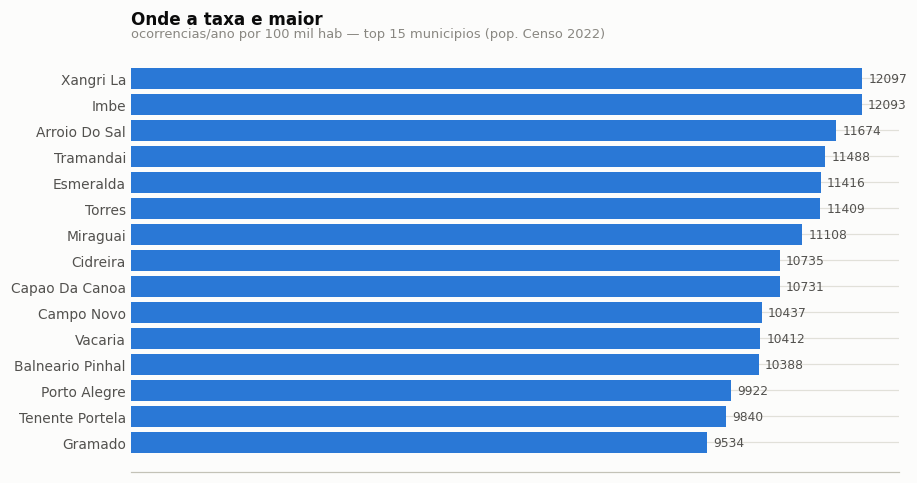

In [5]:
top15 = mun.sort_values("taxa_100k", ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top15["municipio"].str.title(), top15["taxa_100k"], color=viz.SERIES[0])
viz.rotular_barras(ax, "{:.0f}", horizontal=True)
viz.titular(ax, "Onde a taxa e maior",
            "ocorrencias/ano por 100 mil hab — top 15 municipios (pop. Censo 2022)")
viz.salvar(fig, "f3_taxa_municipio"); plt.show()

### 6. Intensidade por mesorregião — Figura 4

Taxa média anual por 100 mil hab. por mesorregião (ponderada pela população).
Responde: a intensidade varia entre regiões do estado?

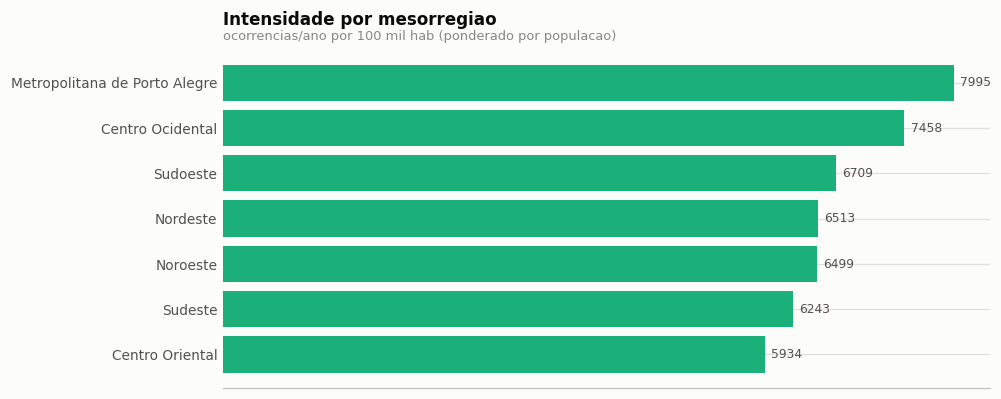

In [6]:
reg = (mun.groupby("mesorregiao")
          .agg(occ=("n_ocorrencias", "sum"), pop=("populacao", "sum"))
          .reset_index())
reg["taxa"] = reg["occ"] / reg["pop"] / n_anos * 1e5
reg = reg.sort_values("taxa")

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(reg["mesorregiao"].str.replace(" Rio-grandense", "", regex=False),
        reg["taxa"], color=viz.SERIES[2])
viz.rotular_barras(ax, "{:.0f}", horizontal=True)
viz.titular(ax, "Intensidade por mesorregiao",
            "ocorrencias/ano por 100 mil hab (ponderado por populacao)")
viz.salvar(fig, "f4_taxa_mesorregiao"); plt.show()

## 7. Teste de hipóteses — o padrão temporal é real?

**Qui-quadrado de independência** entre macrocategoria e turno (crimes de rua).
$H_0$: o tipo de ocorrência é independente do turno (o padrão seria acaso).

In [7]:
ct = pd.crosstab(rua["macro"], rua["turno"])
chi2, p, dof, exp = chi2_contingency(ct)
n = ct.values.sum()
cramer_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"chi2 = {chi2:,.1f} | gl = {dof} | p = {p:.3e} | V de Cramer = {cramer_v:.3f}")
print("H0 rejeitada" if p < 0.05 else "H0 nao rejeitada")

chi2 = 40,606.6 | gl = 24 | p = 0.000e+00 | V de Cramer = 0.114
H0 rejeitada


### Figura 5 — onde o padrão foge do acaso

Resíduos padronizados do χ²: células azuis ocorrem **menos** que o esperado sob
independência; vermelhas, **mais**. Mostra qual crime concentra em qual turno.

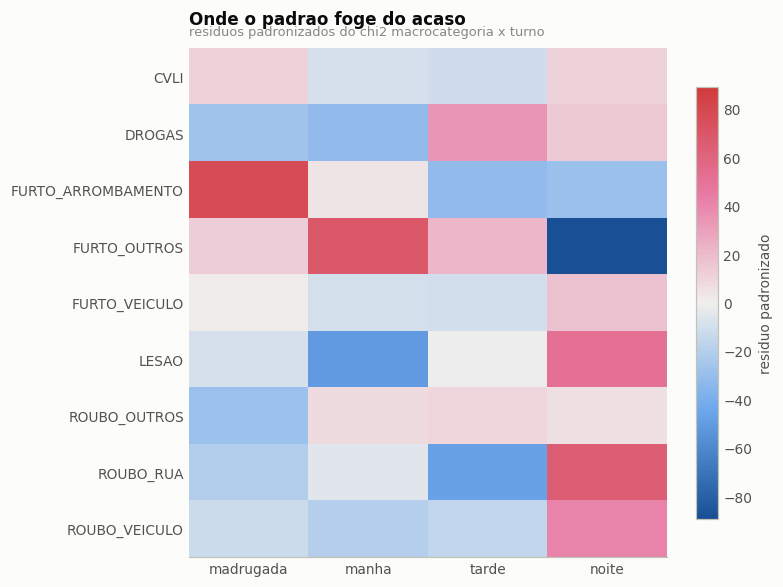

In [8]:
resid = (ct - exp) / np.sqrt(exp)
vmax = np.abs(resid.values).max()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(resid.values, cmap=viz.CMAP_DIVERGENTE, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(ct.shape[1])); ax.set_xticklabels(ct.columns)
ax.set_yticks(range(ct.shape[0])); ax.set_yticklabels(ct.index)
viz.limpar_grade(ax)
fig.colorbar(im, ax=ax, shrink=0.85, label="residuo padronizado")
viz.titular(ax, "Onde o padrao foge do acaso",
            "residuos padronizados do chi2 macrocategoria x turno")
viz.salvar(fig, "f5_residuos_chi2"); plt.show()

## 8. O perfil de crime difere entre regiões?

Dois testes complementares:
- **χ² macrocategoria × mesorregião**: a composição de crimes muda por região?
- **Kruskal-Wallis**: a taxa por 100 mil hab. dos municípios difere entre as
  mesorregiões? (não-paramétrico, não assume normalidade)

In [9]:
ct2 = pd.crosstab(rua["macro"], rua["mesorregiao"])
chi2b, pb, dofb, _ = chi2_contingency(ct2)
vb = np.sqrt(chi2b / (ct2.values.sum() * (min(ct2.shape) - 1)))
print(f"[chi2 macro x mesorregiao] chi2 = {chi2b:,.1f} | gl = {dofb} | "
      f"p = {pb:.3e} | V = {vb:.3f}")

grupos = [g["taxa_100k"].dropna().values for _, g in mun.groupby("mesorregiao")]
H, pk = kruskal(*grupos)
print(f"[Kruskal-Wallis taxa/100k por mesorregiao] H = {H:.1f} | p = {pk:.3e}")

[chi2 macro x mesorregiao] chi2 = 50,367.6 | gl = 48 | p = 0.000e+00 | V = 0.090
[Kruskal-Wallis taxa/100k por mesorregiao] H = 30.3 | p = 3.414e-05


## 9. O turno de pico é o mesmo em toda região? — Figura 7

Cruzamento espaço × tempo: distribuição dos crimes de rua por turno **dentro de
cada mesorregião**. Se o pico fosse diferente por região, a escala de
policiamento teria de mudar de lugar para lugar.

Turno de pico por mesorregiao:


mesorregiao
Centro Ocidental                 noite
Centro Oriental                  noite
Metropolitana de Porto Alegre    noite
Nordeste                         noite
Noroeste                         noite
Sudeste                          noite
Sudoeste                         noite
Categories (4, object): ['madrugada' < 'manha' < 'tarde' < 'noite']


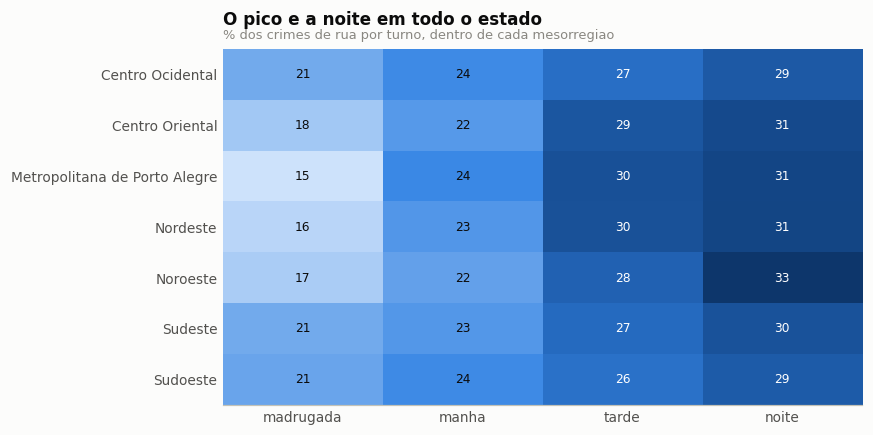

In [10]:
ctr = (pd.crosstab(rua["mesorregiao"], rua["turno"], normalize="index")[viz.ORDEM_TURNO] * 100)
ctr.index = ctr.index.str.replace(" Rio-grandense", "", regex=False)
pico = ctr.idxmax(axis=1)
print("Turno de pico por mesorregiao:")
print(pico.to_string())

fig, ax = plt.subplots(figsize=(7.5, 4.2))
im = ax.imshow(ctr.values, aspect="auto", cmap=viz.CMAP)
ax.set_xticks(range(4)); ax.set_xticklabels(viz.ORDEM_TURNO)
ax.set_yticks(range(len(ctr))); ax.set_yticklabels(ctr.index)
for i in range(ctr.shape[0]):
    for j in range(ctr.shape[1]):
        ax.text(j, i, f"{ctr.values[i, j]:.0f}", ha="center", va="center",
                fontsize=8, color="white" if ctr.values[i, j] > 26 else viz.TINTA["primaria"])
viz.limpar_grade(ax)
viz.titular(ax, "O pico e a noite em todo o estado",
            "% dos crimes de rua por turno, dentro de cada mesorregiao")
viz.salvar(fig, "f7_turno_mesorregiao"); plt.show()

## 10. Sazonalidade: o efeito do veraneio — Figura 6

Distribuição das ocorrências ao longo do ano, no **litoral** (municípios de
veraneio) contra o **resto** do estado. Testa a suspeita de que a taxa do litoral
é inflada pela população flutuante do verão.

grp   litoral  resto
mes                 
1.0      12.5    8.6
2.0      10.6    8.1
3.0       8.7    9.2
4.0       7.4    8.3
5.0       6.9    7.8
6.0       6.8    7.8
7.0       7.1    8.1
8.0       7.4    8.4
9.0       7.0    8.1
10.0      7.7    8.7
11.0      7.7    8.4
12.0     10.3    8.5


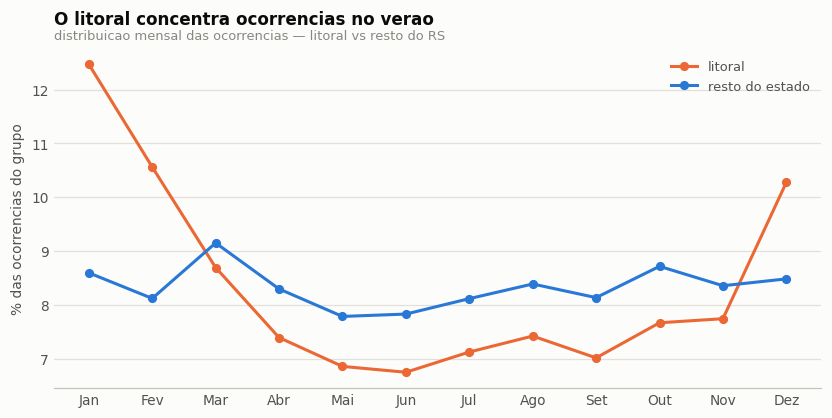

In [11]:
litoral = ["BALNEARIO PINHAL", "IMBE", "ARROIO DO SAL", "TRAMANDAI", "XANGRI LA",
           "CAPAO DA CANOA", "TORRES", "CIDREIRA", "OSORIO", "MOSTARDAS", "TAVARES",
           "PALMARES DO SUL", "DOM PEDRO DE ALCANTARA", "TERRA DE AREIA",
           "TRES CACHOEIRAS", "MAQUINE"]
df["grp"] = np.where(df["municipio"].isin(litoral), "litoral", "resto")
mensal = df.pivot_table(index="mes", columns="grp", aggfunc="size")
mensal = mensal / mensal.sum() * 100
print(mensal.round(1).to_string())

meses = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, 13), mensal["litoral"], marker="o", label="litoral", color=viz.DESTAQUE)
ax.plot(range(1, 13), mensal["resto"], marker="o", label="resto do estado", color=viz.SERIES[0])
ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses)
ax.set_ylabel("% das ocorrencias do grupo")
ax.legend()
viz.titular(ax, "O litoral concentra ocorrencias no verao",
            "distribuicao mensal das ocorrencias — litoral vs resto do RS")
viz.salvar(fig, "f6_sazonalidade_litoral"); plt.show()

### 11. Taxa controlando o tamanho — Figura 3b

O top-15 bruto (Figura 3) é dominado por municípios litorâneos pequenos. Abaixo,
apenas municípios com **50 mil habitantes ou mais**: mostra que taxa alta não é
exclusividade do litoral (aparecem cidades do interior como Vacaria e Cruz Alta).

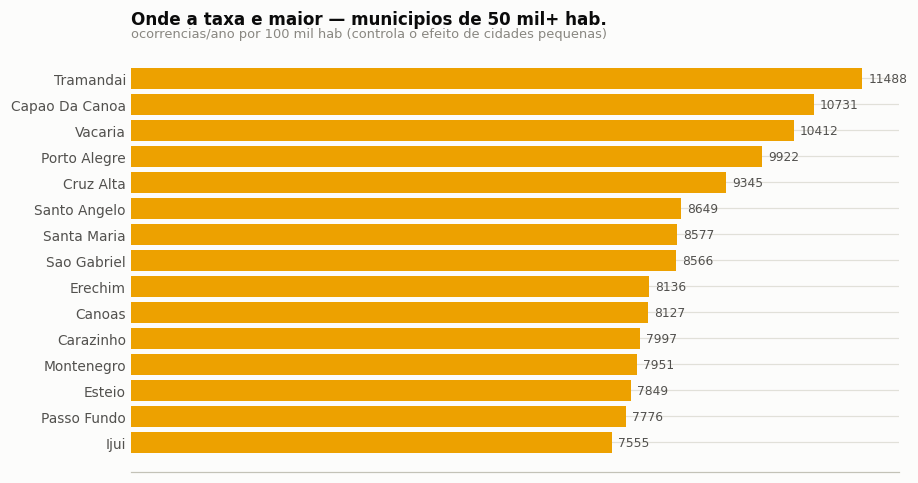

In [12]:
grandes = mun[mun["populacao"] >= 50_000].sort_values("taxa_100k", ascending=False).head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(grandes["municipio"].str.title(), grandes["taxa_100k"], color=viz.SERIES[3])
viz.rotular_barras(ax, "{:.0f}", horizontal=True)
viz.titular(ax, "Onde a taxa e maior — municipios de 50 mil+ hab.",
            "ocorrencias/ano por 100 mil hab (controla o efeito de cidades pequenas)")
viz.salvar(fig, "f3b_taxa_municipio_grandes"); plt.show()

## 12. Conclusão e recomendação

**Existe padrão, e ele é acionável.** Os testes confirmam que a criminalidade no
RS **não** se distribui ao acaso nem no tempo nem no espaço:

- **Tempo:** o tipo de ocorrência depende do turno (χ² = 40.607, p ≈ 0). Mais
  importante que a significância — inevitável com 3,1 milhões de registros — é o
  *padrão* dos resíduos: **arrombamento de madrugada, furto comum de manhã/tarde,
  roubo e lesão à noite**. O V de Cramér (0,11) indica associação real, porém
  **modesta**: o turno molda o *tipo* de crime, não determina *se* haverá crime.
- **Espaço:** a taxa por 100 mil hab. difere entre as mesorregiões
  (Kruskal-Wallis, p ≈ 3×10⁻⁵), da Metropolitana (~8.000/ano) ao Centro Oriental
  (~5.900/ano).
- **Espaço × tempo:** o pico é **a noite em todas as sete mesorregiões**
  (Figura 7) — o padrão temporal é estável no estado inteiro, o que simplifica a
  decisão. A diferença regional está na madrugada, mais pesada no interior.

**Portanto, a recomendação** para a SSP-RS é uma **escala de policiamento por
turno e por tipo dominante**, uniforme quanto ao pico (reforço noturno em todo o
estado) e ajustada na composição: patrulhamento ostensivo noturno contra
roubo/lesão nos centros urbanos, e vigilância de madrugada contra arrombamento,
com peso maior no interior. Na priorização entre municípios, usar a **taxa por
habitante** (Figura 3b), não o volume bruto.

**Com a ressalva de que** (i) o dado é de ocorrência *registrada*, não de crime
real — a subnotificação varia por tipo e região; (ii) a taxa usa a população
residente (Censo 2022), e o litoral aparece inflado pela população de veraneio —
a Figura 6 mostra o litoral saltando para **12,5% das ocorrências em janeiro**
contra 8,6% no resto do estado, confirmando que sua taxa anual superestima o
risco enfrentado pelo morador fixo; e (iii) municípios pequenos têm taxa
instável. A priorização deve, por isso, tratar os municípios litorâneos como
caso sazonal (reforço no verão), não como alta permanente.